# DQRC V3 -- Dual-Route Memory / Nonlinearity Decoupling (Google Colab)

**Scope and warning.** This notebook tests an ARCHITECTURAL correction motivated by the
V2.2 negative results. It does **not** assume the correction succeeds: it implements
falsifiable structural-isolation tests, matched-resource baselines, and preregistered
acceptance gates capable of rejecting the new architecture.

Nothing here claims a broken memory-nonlinearity tradeoff, a quantum advantage, or global
superiority. `SMOKE` results are software validation only; `DISCOVERY` results are
exploratory; only `CONFIRMATION` with held-out seeds can support a scientific claim.

**The four architectures compared** (all built from the SAME memory bank and the SAME
nonlinear processor, so A-vs-B isolates the *architecture*, not a change of modules):

| | route |
|---|---|
| A `serial` | `u -> M(m) --lambda--> P(g,J)` (no direct route) |
| B `dual_route_current` | `u -> M(m)` and `u -> P(g,J)` |
| C `parallel_fixed_taps` | `u -> M(m)` and `(u_t..u_{t-L+1}) -> P(g,J)` |
| D `dual_route_weak` | B plus `M --lambda--> P` |

V1/V2/V2.1/V2.2 notebooks, reports and results are never modified by this notebook.

## 2. Colab detection and (optional) Google Drive

Drive is optional. When mounted, results and checkpoints persist there so a Colab
disconnection does not lose completed work.

In [1]:
# --- user-facing settings (the only cell you normally edit) -------------------
RUN_MODE = "SMOKE"            # "SMOKE" | "DISCOVERY" | "CONFIRMATION"
USE_GOOGLE_DRIVE = True        # ignored automatically when not running in Colab
FORCE_RECOMPUTE = False
CONFIRM_EXPENSIVE_RUN = False  # must be True to actually execute DISCOVERY/CONFIRMATION work
ARCHITECTURES = [
    "serial",
    "dual_route_current",
    "parallel_fixed_taps",
    "dual_route_weak",
]

REPO_URL = "https://github.com/chinmoybiswasdeep/masters-thesis-cpsr-dvqc"
REPO_BRANCH = "qiskit"
COLAB_REPO_ROOT = "/content/masters-thesis-cpsr-dvqc"
DRIVE_RESULTS_ROOT = "/content/drive/MyDrive/dqrc_dual_route_v3"
# -----------------------------------------------------------------------------

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False
print(f"IN_COLAB = {IN_COLAB}")

DRIVE_MOUNTED = False
if IN_COLAB and USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        DRIVE_MOUNTED = True
    except Exception as exc:
        print(f"Drive mount skipped ({exc}); results will stay in the repository checkout.")
print(f"DRIVE_MOUNTED = {DRIVE_MOUNTED}")

IN_COLAB = False
DRIVE_MOUNTED = False


## 3. Repository and dependency setup

The repository is cloned only if it is not already present. No tokens or credentials are
embedded: for a private repository, either clone it yourself into `COLAB_REPO_ROOT` before
running, or use Colab's GitHub integration.

In [2]:
import os, subprocess, sys

if IN_COLAB:
    REPO_ROOT = COLAB_REPO_ROOT
    if not os.path.isdir(REPO_ROOT):
        print(f"cloning {REPO_URL} (branch {REPO_BRANCH}) ...")
        rc = subprocess.run(["git", "clone", "--branch", REPO_BRANCH, REPO_URL, REPO_ROOT]).returncode
        if rc != 0:
            print("Clone failed. If the repository is private, clone it manually into "
                  f"{REPO_ROOT} (e.g. via Colab's GitHub integration) and re-run this cell.")
    else:
        print(f"repository already present at {REPO_ROOT}")
else:
    # running locally: this notebook lives in <repo>/code
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
print(f"REPO_ROOT = {REPO_ROOT}")

CODE_DIR = os.path.join(REPO_ROOT, "code")
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

REPO_ROOT = D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc


In [3]:
# Dependencies: install ONLY what is missing, so a warm Colab runtime is not disturbed.
REQUIRED = {"qiskit": "qiskit", "qiskit_aer": "qiskit-aer", "scipy": "scipy",
            "sklearn": "scikit-learn", "matplotlib": "matplotlib"}
missing = []
for mod, pkg in REQUIRED.items():
    try:
        __import__(mod)
    except ImportError:
        missing.append(pkg)

if missing and IN_COLAB:
    print("installing:", missing)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=False)
elif missing:
    print("missing (install manually when running locally):", missing)
else:
    print("all dependencies already present")

# GPU is optional and never required; qiskit-aer-gpu is NOT assumed.
try:
    from qiskit_aer import AerSimulator
    GPU_AVAILABLE = "GPU" in AerSimulator().available_devices()
except Exception:
    GPU_AVAILABLE = False
print(f"GPU_AVAILABLE = {GPU_AVAILABLE} (CPU is used by default either way)")

all dependencies already present
GPU_AVAILABLE = False (CPU is used by default either way)


## 4. Runtime, paths and reproducibility metadata

In [4]:
import json, time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from decoupled_qrc.colab_support import resolve_paths, runtime_metadata, estimate_runtime, Checkpointer
from decoupled_qrc.v3_cache import (environment_fingerprint, canonical_key, set_cache_root,
                                     CACHE_SCHEMA_VERSION)

PATHS = resolve_paths(repo_root=REPO_ROOT,
                       drive_results_root=(DRIVE_RESULTS_ROOT if DRIVE_MOUNTED else None),
                       use_drive=DRIVE_MOUNTED)
set_cache_root(PATHS.cache_root)
CKPT = Checkpointer(PATHS.checkpoint_root, force_recompute=FORCE_RECOMPUTE)

RESULTS_DIR = str(PATHS.results_root)
REPO_RESULTS_DIR = os.path.join(REPO_ROOT, "results", "dqrc_dual_route_v3")
os.makedirs(REPO_RESULTS_DIR, exist_ok=True)

META = runtime_metadata()
ENV = environment_fingerprint()
print(json.dumps({**META, **ENV}, indent=2))
print(f"\nresults      -> {RESULTS_DIR}")
print(f"checkpoints  -> {PATHS.checkpoint_root}   (persistent={PATHS.persistent})")
print(f"cache schema -> {CACHE_SCHEMA_VERSION}")

if RUN_MODE == "SMOKE":
    print("\n" + "=" * 78)
    print("SMOKE MODE RESULTS ARE FOR SOFTWARE VALIDATION ONLY AND MUST NOT BE USED FOR")
    print("SCIENTIFIC CLAIMS.")
    print("=" * 78)
elif RUN_MODE == "DISCOVERY":
    print("\nDISCOVERY MODE: exploratory only. These are NOT held-out confirmation results.")

_RESULTS, _MANIFEST, _FIGN = {}, [], [0]

def record(key, value):
    _RESULTS[key] = value

def savefig(fig, name, data_file, metric, seeds_desc):
    _FIGN[0] += 1
    stem = f"{_FIGN[0]:02d}_{name}"
    for ext in ("png", "pdf"):
        for root in {RESULTS_DIR, REPO_RESULTS_DIR}:
            fig.savefig(os.path.join(root, f"{stem}.{ext}"), dpi=130, bbox_inches="tight")
    _MANIFEST.append({"figure": f"{stem}.png", "run_mode": RUN_MODE, "metric_definition": metric,
                       "seeds": seeds_desc, "source_data_file": data_file,
                       "capacity_estimator": "signed bias-corrected (C_raw - mu_null), unclipped"})
    return stem

{
  "in_colab": false,
  "python": "3.14.4",
  "platform": "Windows-11-10.0.26200-SP0",
  "gpu_available": false,
  "timestamp": "2026-09-18T00:45:58Z",
  "qiskit_version": "2.5.2",
  "qiskit_aer_version": "0.17.2",
  "numpy_version": "2.5.2",
  "scipy_version": "1.18.1",
  "sklearn_version": "1.9.0",
  "matplotlib_version": "3.11.1",
  "ram_gb": 25.46,
  "schema_version": "v3.0.0",
  "git_commit": "a1ba7a94345fcab9a86727898e8ae5c7cdc71470",
  "qiskit": "2.5.2",
  "qiskit_aer": "0.17.2",
  "sklearn": "1.9.0",
  "precision": "complex128",
  "simulator": "aer_density_matrix"
}

results      -> D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_dual_route_v3
checkpoints  -> D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_dual_route_v3\_checkpoints   (persistent=False)
cache schema -> v3.0.0

SMOKE MODE RESULTS ARE FOR SOFTWARE VALIDATION ONLY AND MUST NOT BE USED FOR
SCIENTIFIC CLAIMS.


## 5. Mode configuration

`SMOKE` exercises every code path at minimal scale. `DISCOVERY` and `CONFIRMATION` are
gated behind `CONFIRM_EXPENSIVE_RUN` after printing a runtime estimate.

In [5]:
if RUN_MODE == "SMOKE":
    CFG = dict(T=90, washout=12, n_val=18, n_test=22, max_delay=4, max_degree=3,
                max_targets_per_degree=6, n_surrogates=19, n_reservoir_seeds=2, n_input_seeds=1,
                L_memory=3, N_P=3, R=2, tap_depth=3, lambdas=[0.0, 0.05, 0.2], n_projection_repeats=5,
                m_scan=[0.3, 0.6, 0.9])
elif RUN_MODE == "DISCOVERY":
    CFG = dict(T=260, washout=30, n_val=45, n_test=55, max_delay=7, max_degree=4,
                max_targets_per_degree=12, n_surrogates=49, n_reservoir_seeds=3, n_input_seeds=2,
                L_memory=4, N_P=4, R=3, tap_depth=4, lambdas=[0.0, 0.02, 0.05, 0.10, 0.20],
                n_projection_repeats=20, m_scan=[0.2, 0.4, 0.6, 0.8, 0.95])
else:  # CONFIRMATION
    CFG = dict(T=600, washout=60, n_val=110, n_test=140, max_delay=10, max_degree=5,
                max_targets_per_degree=20, n_surrogates=199, n_reservoir_seeds=5, n_input_seeds=3,
                L_memory=4, N_P=4, R=3, tap_depth=4, lambdas=[0.0, 0.02, 0.05, 0.10, 0.20],
                n_projection_repeats=50, m_scan=[0.2, 0.4, 0.6, 0.8, 0.95])

M_STAR, G_STAR, J_STAR = 0.70, 0.80, 0.60      # frozen central operating point
M_RANGE, G_RANGE, J_RANGE = (0.10, 0.95), (0.20, 1.40), (0.10, 1.10)
H_SMALL, H_LARGE = 0.05, 0.10                   # dimensionless stencil steps

print(f"RUN_MODE={RUN_MODE}")
print(json.dumps(CFG, indent=2))
record("run_mode", RUN_MODE)
record("config", CFG)
record("environment", {**META, **ENV})
record("operating_point", {"m": M_STAR, "g": G_STAR, "J": J_STAR,
                            "m_range": M_RANGE, "g_range": G_RANGE, "J_range": J_RANGE,
                            "h_small": H_SMALL, "h_large": H_LARGE})

n_arch = len(ARCHITECTURES)
n_sims = (n_arch * CFG["n_reservoir_seeds"] * CFG["n_input_seeds"]
           + len(CFG["lambdas"]) + len(CFG["m_scan"]) + 12)
EST = estimate_runtime(n_simulations=n_sims, seconds_per_simulation=(2.0 if RUN_MODE == "SMOKE" else 12.0),
                        n_qubits=CFG["L_memory"] + CFG["N_P"])
print("\nRUNTIME ESTIMATE:", EST.summary())
record("runtime_estimate", EST.as_dict())

EXPENSIVE = RUN_MODE in ("DISCOVERY", "CONFIRMATION")
RUN_WORK = (not EXPENSIVE) or CONFIRM_EXPENSIVE_RUN
if EXPENSIVE and not CONFIRM_EXPENSIVE_RUN:
    print("\nCONFIRM_EXPENSIVE_RUN is False -> printing the PLAN only, not executing the "
          "expensive stages. Set it to True to run them.")

RUN_MODE=SMOKE
{
  "T": 90,
  "washout": 12,
  "n_val": 18,
  "n_test": 22,
  "max_delay": 4,
  "max_degree": 3,
  "max_targets_per_degree": 6,
  "n_surrogates": 19,
  "n_reservoir_seeds": 2,
  "n_input_seeds": 1,
  "L_memory": 3,
  "N_P": 3,
  "R": 2,
  "tap_depth": 3,
  "lambdas": [
    0.0,
    0.05,
    0.2
  ],
  "n_projection_repeats": 5,
  "m_scan": [
    0.3,
    0.6,
    0.9
  ]
}

RUNTIME ESTIMATE: 26 simulations x ~2.00s = ~0.9 min, peak ~0 MB


## 6. Load and audit the V2.2 evidence

Every V2.2 observation V3 is built on is re-read from the saved result files rather than
assumed. Where the repository disagrees with the stated summary, the repository value
wins and the discrepancy is reported.

In [6]:
from decoupled_qrc.operator_bounds import audit_v22_operator_entanglement
from decoupled_qrc.safe_ratio import retained_nl_safe

V22_PATH = os.path.join(REPO_ROOT, "results", "dqrc_gj_validation_v2_2", "validation_v2_2_results.json")
audit = {"v22_results_found": os.path.exists(V22_PATH)}

if audit["v22_results_found"]:
    with open(V22_PATH) as f:
        V22 = json.load(f)
    delays = V22["phase2_three_delays"]
    eta = V22["phase6_retained_nl"]["eta_NL_by_delay"]
    screen = V22["phase8_screening_table"]
    audit.update({
        "ell_causal": delays["ell_causal"], "ell_peak": delays["ell_peak"],
        "peak_is_not_causal": not delays["causal_equals_peak"],
        "eta_NL_0": eta["0"],
        "eta_NL_exploded_somewhere": any(abs(v) > 1e3 for v in eta.values()),
        "max_eta": max(eta.values()),
        "n_screen_rows": len(screen),
        "n_with_nontrivial_NL0": sum(1 for r in screen if r["NL_0_signed"] > 0.05),
        "gate_b": V22["gate_b_result"],
        "derivative_stability": V22["phase10_derivative_stability"],
        "reset": {r["K"]: {"M": r["M_signed"], "NL0": r["NL_0_signed"]}
                   for r in V22["phase11_reset_fixed_delay"]},
        "backaction": {k: v["mean"] for k, v in V22["phase13_backaction_decomposition"].items()},
        "ranking_score_of_single_valid_candidate": V22["phase8_ranking"],
        "advancement_checks": V22["phase15_advancement_decision"]["checks"],
    })
    print(f"1. ell_causal={audit['ell_causal']} vs ell_peak={audit['ell_peak']} "
          f"-> peak delay is NOT the causal latency: {audit['peak_is_not_causal']}")
    print(f"2. eta_NL(0) = {audit['eta_NL_0']:.3f}")
    print(f"3. nontrivial NL_0 in {audit['n_with_nontrivial_NL0']}/{audit['n_screen_rows']} screening rows")
    print(f"5. Gate B (derivative stability) = {audit['gate_b']}; "
          f"{sum(1 for v in audit['derivative_stability'].values() if v=='STABLE')}/6 STABLE")
    print(f"6. reset: {audit['reset']}")
    print(f"7. back-action: {audit['backaction']}")
    print(f"10a. ratio explosion present: {audit['eta_NL_exploded_somewhere']} (max eta = {audit['max_eta']:.3g})")
    print(f"10b. single VALID candidate scored: {audit['ranking_score_of_single_valid_candidate']}")
    print(f"10c. 'not driven by one seed' check said: "
          f"{audit['advancement_checks']['7_not_driven_by_one_seed']} "
          f"while only {audit['n_with_nontrivial_NL0']}/{audit['n_screen_rows']} rows showed NL")
else:
    print(f"V2.2 results not found at {V22_PATH}; V3 proceeds without the audit cross-check.")

# 10d: the invalid chaos normalisation, re-derived
audit["operator_entanglement_audit"] = audit_v22_operator_entanglement()
oe = audit["operator_entanglement_audit"]
print(f"\n10d. operator entanglement {oe['value']:.4f}: exceeds the bound the repository PRINTED "
      f"({oe['repository_printed_bound']:.4f}) = {oe['exceeds_repository_printed_bound']}; "
      f"legal under the CORRECT operator bound ({oe['correct_bound']:.4f}) = {oe['valid_under_correct_bound']}")

# 10a: demonstrate the V3 handler refuses the exact exploding case
demo = retained_nl_safe(0.0379, -0.0300)
print(f"10a fix: eta for (num=0.0379, den=-0.0300) is now "
      f"evaluable={demo.evaluable}, reason='{demo.rejection_reason}'")
audit["ratio_fix_demo"] = demo.as_dict()
record("v22_audit", audit)

1. ell_causal=0 vs ell_peak=7 -> peak delay is NOT the causal latency: True
2. eta_NL(0) = 0.229
3. nontrivial NL_0 in 1/8 screening rows
5. Gate B (derivative stability) = FAIL; 1/6 STABLE
6. reset: {'1': {'M': 0.6351039887233763, 'NL0': -0.0033865175624604726}, '4': {'M': 1.6915000671852143, 'NL0': 0.17436154679658508}, 'None': {'M': 5.259192631034168, 'NL0': 0.7311984681543531}}
7. back-action: {'full': 0.043347356034955514, 'memory_export_disabled': 1.4983005397718842e-16, 'processor_reception_disabled': 0.04334735603495556}
10a. ratio explosion present: True (max eta = 3.75e+07)
10b. single VALID candidate scored: {'n_valid': 1, 'top_candidate': {'m': 0.212, 'g': 0.405, 'J': 0.205}}
10c. 'not driven by one seed' check said: True while only 1/8 rows showed NL

10d. operator entanglement 1.7537: exceeds the bound the repository PRINTED (1.3863) = True; legal under the CORRECT operator bound (2.7726) = True
10a fix: eta for (num=0.0379, den=-0.0300) is now evaluable=False, reason='de

## 7. Why the serial architecture cannot guarantee control separation

In `u -> M(m) -> A -> P(g,J)` every signal reaching the processor has already passed
through the `m`-dependent memory. One-way transfer suppresses `P -> M` back-action but
does nothing about `M(m) -> P`, so `dNL/dm` is generically nonzero -- a structural
property, not a tuning problem. V3 tests whether separating the INPUT ROUTES removes it.

The next section measures this directly rather than arguing it.

## 8. Define the V3 architectures and verify structural feature isolation

The decisive test: perturb `m` and check whether the processor features move at all;
perturb `(g,J)` and check whether the memory features move at all. Tolerance
`atol = 1e-10` is set by float64 round-off, far below any physical effect. The test is
falsifiable -- an injected hidden `m -> processor` dependency must make it FAIL.

serial                 dX_P/dm=1.421e-01  dX_M/dg=2.813e-02  dX_M/dJ=4.716e-02  -> FAIL


dual_route_current     dX_P/dm=0.000e+00  dX_M/dg=0.000e+00  dX_M/dJ=0.000e+00  -> PASS


parallel_fixed_taps    dX_P/dm=0.000e+00  dX_M/dg=0.000e+00  dX_M/dJ=0.000e+00  -> PASS


dual_route_weak        dX_P/dm=0.000e+00  dX_M/dg=0.000e+00  dX_M/dJ=0.000e+00  -> PASS



falsifiability control (injected hidden m->P dependency): passed=False (must be False), max|dX_P/dm|=1.787e-02


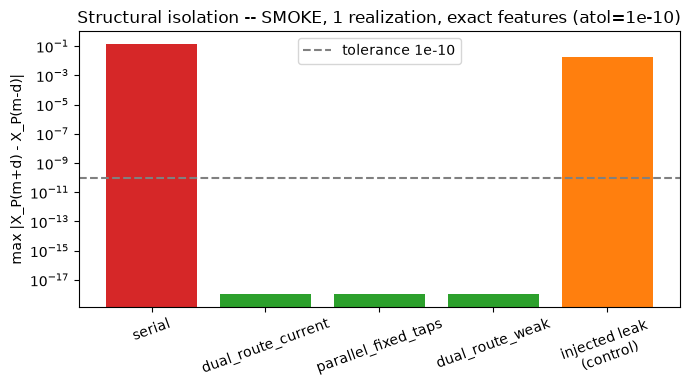

In [7]:
from dataclasses import replace
from decoupled_qrc.dual_route import DualRouteConfig, run_architecture
from decoupled_qrc.memory_bank import MemoryBankConfig
from decoupled_qrc.nonlinear_processor import ProcessorConfig, run_processor, build_tap_buffer
from decoupled_qrc.isolation import check_structural_isolation, inject_cross_dependency, ATOL
from decoupled_qrc.v3_seeds import make_seeds, discovery_seeds, confirmation_seeds
from decoupled_qrc.v3_analysis import (analyse_architecture_run, analyse_feature_group,
                                        frozen_readout_intervention, matched_resource_row)

def build_cfg(architecture, m=M_STAR, g=G_STAR, J=J_STAR, lam=0.0):
    return DualRouteConfig(
        architecture=architecture,
        memory=MemoryBankConfig(L=CFG["L_memory"], m=m),
        processor=ProcessorConfig(N_P=CFG["N_P"], g=g, J=J, R=CFG["R"]),
        lam=lam, lam_serial=0.5, tap_depth=CFG["tap_depth"])

ANALYSIS_KW = dict(washout=CFG["washout"], n_val=CFG["n_val"], n_test=CFG["n_test"],
                    max_delay=CFG["max_delay"], max_degree=CFG["max_degree"],
                    max_targets_per_degree=CFG["max_targets_per_degree"],
                    n_surrogates=CFG["n_surrogates"])

iso_seeds = discovery_seeds(0, 0)
T_iso = min(CFG["T"], 40)
isolation_rows = []
for arch in ARCHITECTURES:
    res = check_structural_isolation(build_cfg(arch), T=T_iso, seeds=iso_seeds)
    isolation_rows.append({"architecture": arch, "max_abs_dXP_dm": res.max_abs_dXP_dm,
                            "max_abs_dXM_dg": res.max_abs_dXM_dg, "max_abs_dXM_dJ": res.max_abs_dXM_dJ,
                            "hamiltonian_identical": res.processor_hamiltonian_identical,
                            "passed": res.passed, "failures": res.failures})
    print(f"{arch:22s} dX_P/dm={res.max_abs_dXP_dm:.3e}  dX_M/dg={res.max_abs_dXM_dg:.3e}  "
          f"dX_M/dJ={res.max_abs_dXM_dJ:.3e}  -> {'PASS' if res.passed else 'FAIL'}")

leak = check_structural_isolation(build_cfg("dual_route_current"), T=T_iso, seeds=iso_seeds,
                                   run_fn=inject_cross_dependency(0.1))
print(f"\nfalsifiability control (injected hidden m->P dependency): passed={leak.passed} "
      f"(must be False), max|dX_P/dm|={leak.max_abs_dXP_dm:.3e}")
record("structural_isolation", {"atol": ATOL, "rows": isolation_rows,
                                 "falsifiability_control": {"passed": leak.passed,
                                                             "max_abs_dXP_dm": leak.max_abs_dXP_dm}})

fig, ax = plt.subplots(figsize=(7, 4))
names = [r["architecture"] for r in isolation_rows]
vals = [max(r["max_abs_dXP_dm"], 1e-18) for r in isolation_rows]
colors = ["tab:green" if r["passed"] else "tab:red" for r in isolation_rows]
ax.bar(names, vals, color=colors)
ax.bar(["injected leak\n(control)"], [max(leak.max_abs_dXP_dm, 1e-18)], color="tab:orange")
ax.axhline(ATOL, color="gray", ls="--", label=f"tolerance {ATOL:.0e}")
ax.set_yscale("log"); ax.set_ylabel("max |X_P(m+d) - X_P(m-d)|"); ax.legend()
ax.tick_params(axis="x", rotation=20)
ax.set_title(f"Structural isolation -- {RUN_MODE}, 1 realization, exact features (atol={ATOL:.0e})")
fig.tight_layout(); savefig(fig, "structural_isolation", "validation_v3_results.json:structural_isolation",
                            "max abs feature difference under +/- m perturbation", "1 reservoir seed")
plt.show()

## 9. Validate the memory module separately

`m` is the fractional-SWAP exponent of the rail-to-rail routing: `SWAP^m`. `m=1` is a
perfect shift register (maximal retention); `m=0` transfers nothing. It is a physically
implemented channel parameter -- it does not change the delay horizon, the target set, the
readout regularization, the feature count, or the number of observables.

m=0.3   M_signed=+1.478  ceiling=0.27 (contaminated=False)  eff_rank=5.11  n_features=36


m=0.6   M_signed=+2.677  ceiling=0.69 (contaminated=False)  eff_rank=6.87  n_features=36


m=0.9   M_signed=+3.450  ceiling=0.83 (contaminated=False)  eff_rank=6.22  n_features=36

feature count constant across m: True {36}


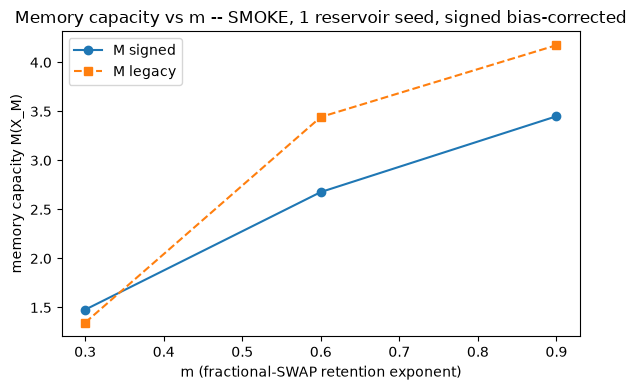

In [8]:
from decoupled_qrc.memory_bank import run_memory_bank, to_signed
from qrc_qiskit import chrono_split, random_input

mem_seeds = discovery_seeds(1, 0)
u_mem = random_input(CFG["T"], seed=mem_seeds.input_sequence)
gap = CFG["max_delay"] + 1
tr, va, te = chrono_split(CFG["T"], CFG["washout"], CFG["n_val"], CFG["n_test"], gap)

mem_rows = []
for m_val in CFG["m_scan"]:
    run = run_memory_bank(MemoryBankConfig(L=CFG["L_memory"], m=m_val), u_mem, mem_seeds)
    rep = analyse_feature_group(f"X_M(m={m_val})", u_mem, run.X_M, tr, va, te,
                                 max_delay=CFG["max_delay"], max_degree=CFG["max_degree"],
                                 max_targets_per_degree=CFG["max_targets_per_degree"],
                                 n_surrogates=CFG["n_surrogates"], seed=mem_seeds.null_surrogate)
    mem_rows.append({"m": m_val, "M_signed": rep.M_signed, "M_raw": rep.M_raw, "M_null": rep.M_null,
                      "M_legacy": rep.M_legacy, "NL0_signed": rep.NL0_signed,
                      "effective_rank": rep.effective_rank, "n_features": rep.n_features,
                      "ceiling_fraction": rep.ceiling_fraction,
                      "ceiling_contaminated": bool(rep.ceiling_contaminated),
                      "sample_to_effective_rank": rep.sample_to_effective_rank,
                      "nl_by_delay_signed": rep.nl_by_delay_signed})
    print(f"m={m_val:<5} M_signed={rep.M_signed:+.3f}  ceiling={rep.ceiling_fraction:.2f} "
          f"(contaminated={rep.ceiling_contaminated})  eff_rank={rep.effective_rank:.2f}  "
          f"n_features={rep.n_features}")

feature_counts = {r["n_features"] for r in mem_rows}
print(f"\nfeature count constant across m: {len(feature_counts) == 1} {feature_counts}")
record("memory_scan", mem_rows)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([r["m"] for r in mem_rows], [r["M_signed"] for r in mem_rows], "o-", label="M signed")
ax.plot([r["m"] for r in mem_rows], [r["M_legacy"] for r in mem_rows], "s--", label="M legacy")
ax.set_xlabel("m (fractional-SWAP retention exponent)"); ax.set_ylabel("memory capacity M(X_M)")
ax.legend(); ax.set_title(f"Memory capacity vs m -- {RUN_MODE}, 1 reservoir seed, signed bias-corrected")
fig.tight_layout(); savefig(fig, "memory_capacity_vs_m", "validation_v3_results.json:memory_scan",
                            "M(X_M), signed bias-corrected", "1 reservoir x 1 input seed")
plt.show()

## 10. Validate the nonlinear processor separately

The standalone processor is the matched baseline: same Hamiltonian, encoding, features,
seeds and regression protocol as when embedded. `eta_NL` uses the SAFE ratio handler --
a near-zero or negative denominator returns `NOT EVALUABLE`, never a huge number.

standalone processor: NL0_signed=+1.4040 (raw=2.000, null=0.596, legacy=1.000)  M_signed=+0.531  eff_rank=1.38


  g=0.4  J=0.4  NL0_signed=+1.4046


  g=0.4  J=0.8  NL0_signed=+1.4243


  g=0.4  J=1.2  NL0_signed=+1.4038


  g=0.8  J=0.4  NL0_signed=+1.4113


  g=0.8  J=0.8  NL0_signed=+1.4059


  g=0.8  J=1.2  NL0_signed=+1.4048


  g=1.2  J=0.4  NL0_signed=+1.4055


  g=1.2  J=0.8  NL0_signed=+1.4142


  g=1.2  J=1.2  NL0_signed=+1.4247


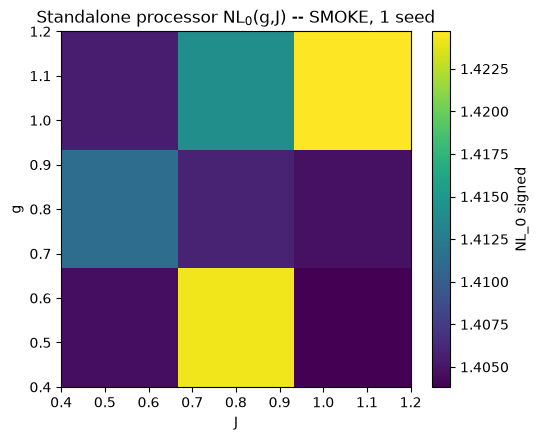

In [9]:
proc_seeds = discovery_seeds(2, 0)
u_proc = random_input(CFG["T"], seed=proc_seeds.input_sequence)

standalone_cfg = ProcessorConfig(N_P=CFG["N_P"], g=G_STAR, J=J_STAR, R=CFG["R"], n_taps=1)
sa_run = run_processor(standalone_cfg, build_tap_buffer(u_proc, 1), proc_seeds)
sa_rep = analyse_feature_group("X_P_standalone", u_proc, sa_run.X_P, tr, va, te,
                                max_delay=CFG["max_delay"], max_degree=CFG["max_degree"],
                                max_targets_per_degree=CFG["max_targets_per_degree"],
                                n_surrogates=CFG["n_surrogates"], seed=proc_seeds.null_surrogate)
print(f"standalone processor: NL0_signed={sa_rep.NL0_signed:+.4f} "
      f"(raw={sa_rep.NL0_raw:.3f}, null={sa_rep.NL0_null:.3f}, legacy={sa_rep.NL0_legacy:.3f})  "
      f"M_signed={sa_rep.M_signed:+.3f}  eff_rank={sa_rep.effective_rank:.2f}")
record("standalone_processor", {"NL0_signed": sa_rep.NL0_signed, "NL0_raw": sa_rep.NL0_raw,
                                 "NL0_null": sa_rep.NL0_null, "NL0_positive": sa_rep.NL0_positive,
                                 "NL0_legacy": sa_rep.NL0_legacy, "M_signed": sa_rep.M_signed,
                                 "effective_rank": sa_rep.effective_rank,
                                 "n_features": sa_rep.n_features})

# (g, J) surface at reduced resolution
grid = [0.4, 0.8, 1.2] if RUN_MODE == "SMOKE" else [0.3, 0.6, 0.9, 1.2]
surface = []
for g_val in grid:
    for J_val in grid:
        r = run_processor(ProcessorConfig(N_P=CFG["N_P"], g=g_val, J=J_val, R=CFG["R"], n_taps=1),
                           build_tap_buffer(u_proc, 1), proc_seeds)
        rep = analyse_feature_group("s", u_proc, r.X_P, tr, va, te, max_delay=CFG["max_delay"],
                                     max_degree=CFG["max_degree"],
                                     max_targets_per_degree=CFG["max_targets_per_degree"],
                                     n_surrogates=CFG["n_surrogates"], seed=proc_seeds.null_surrogate)
        surface.append({"g": g_val, "J": J_val, "NL0_signed": rep.NL0_signed, "M_signed": rep.M_signed})
        print(f"  g={g_val:<4} J={J_val:<4} NL0_signed={rep.NL0_signed:+.4f}")
record("processor_surface", surface)

mat = np.array([s["NL0_signed"] for s in surface]).reshape(len(grid), len(grid))
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(mat, origin="lower", cmap="viridis",
                extent=[min(grid), max(grid), min(grid), max(grid)], aspect="auto")
ax.set_xlabel("J"); ax.set_ylabel("g"); fig.colorbar(im, ax=ax, label="NL_0 signed")
ax.set_title(f"Standalone processor NL$_0$(g,J) -- {RUN_MODE}, 1 seed")
fig.tight_layout(); savefig(fig, "processor_nl_surface", "validation_v3_results.json:processor_surface",
                            "NL_tau=0 (X_P), signed bias-corrected", "1 reservoir x 1 input seed")
plt.show()

## 11. Architecture comparison and retained nonlinear capacity

Every architecture is run on MATCHED input sequences and matched Hamiltonian seeds, and
every comparison carries its resource accounting (qubits, observables, depth, and the
classical tap-buffer size for Architecture C).

serial                 M(X_M)=+3.159  NL0(X_P)=+0.0000 +/-0.0000  eta_NL0=0.000  qubits=6  taps=0


dual_route_current     M(X_M)=+3.295  NL0(X_P)=+1.2156 +/-0.0594  eta_NL0=0.866  qubits=6  taps=0


parallel_fixed_taps    M(X_M)=+3.295  NL0(X_P)=+1.7410 +/-0.0580  eta_NL0=1.240  qubits=6  taps=3


dual_route_weak        M(X_M)=+2.980  NL0(X_P)=+1.2883 +/-0.0144  eta_NL0=0.918  qubits=6  taps=0

architecture comparison wall time: 93.3s


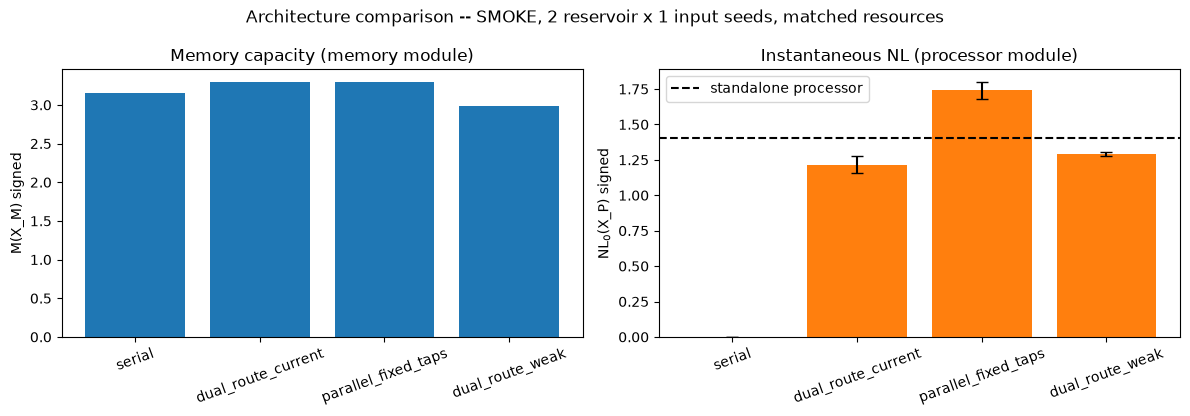

In [10]:
arch_reports, arch_rows, resource_rows = {}, [], []
t_start = time.perf_counter()
for arch in ARCHITECTURES:
    per_seed = []
    for r_idx in range(CFG["n_reservoir_seeds"]):
        for i_idx in range(CFG["n_input_seeds"]):
            seeds = discovery_seeds(10 + r_idx, i_idx)
            key = canonical_key(stage="arch_compare", arch=arch, cfg=CFG, seeds=seeds.as_dict(),
                                 m=M_STAR, g=G_STAR, J=J_STAR, lam=0.05, env=ENV)
            cached = CKPT.load("arch_compare", f"{arch}_r{r_idx}_i{i_idx}", key)
            if cached is not None:
                per_seed.append(cached); continue
            run = run_architecture(build_cfg(arch, lam=0.05), CFG["T"], seeds)
            rep = analyse_architecture_run(run, seeds, **ANALYSIS_KW)
            row = {"architecture": arch, "reservoir_idx": seeds.reservoir_idx,
                    "input_idx": seeds.input_idx, "M_memory": rep.M_memory,
                    "NL0_processor": rep.NL_instant_processor,
                    "NL_temporal_processor": rep.groups["X_P"].NL_temporal_signed,
                    "NL0_combined": rep.groups["X_M+X_P"].NL0_signed,
                    "M_combined": rep.groups["X_M+X_P"].M_signed,
                    "NL0_residualized": rep.groups["X_P_perp"].NL0_signed,
                    "n_qubits": rep.n_qubits, "n_observables": rep.n_observables,
                    "circuit_depth": rep.circuit_depth, "tap_buffer": rep.tap_buffer_size}
            CKPT.save("arch_compare", f"{arch}_r{r_idx}_i{i_idx}", key, row)
            per_seed.append(row)
            arch_reports[(arch, r_idx, i_idx)] = rep
    arch_rows.extend(per_seed)
    m_vals = [r["M_memory"] for r in per_seed]
    nl_vals = [r["NL0_processor"] for r in per_seed]
    eta = retained_nl_safe(float(np.mean(nl_vals)), sa_rep.NL0_signed)
    resource_rows.append({"architecture": arch, "M_memory_mean": float(np.mean(m_vals)),
                           "NL0_processor_mean": float(np.mean(nl_vals)),
                           "NL0_processor_std": float(np.std(nl_vals)),
                           "eta_NL0": eta.ratio if eta.evaluable else None,
                           "eta_evaluable": eta.evaluable, "eta_reason": eta.rejection_reason,
                           "n_qubits": per_seed[0]["n_qubits"],
                           "n_observables": per_seed[0]["n_observables"],
                           "circuit_depth": per_seed[0]["circuit_depth"],
                           "classical_tap_buffer": per_seed[0]["tap_buffer"]})
    eta_txt = f"{eta.ratio:.3f}" if eta.evaluable else f"NOT EVALUABLE ({eta.rejection_reason})"
    print(f"{arch:22s} M(X_M)={np.mean(m_vals):+.3f}  NL0(X_P)={np.mean(nl_vals):+.4f}"
          f" +/-{np.std(nl_vals):.4f}  eta_NL0={eta_txt}  qubits={per_seed[0]['n_qubits']}"
          f"  taps={per_seed[0]['tap_buffer']}")
print(f"\narchitecture comparison wall time: {time.perf_counter()-t_start:.1f}s")
record("architecture_rows", arch_rows)
record("architecture_summary", resource_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
names = [r["architecture"] for r in resource_rows]
axes[0].bar(names, [r["M_memory_mean"] for r in resource_rows], color="tab:blue")
axes[0].set_ylabel("M(X_M) signed"); axes[0].set_title("Memory capacity (memory module)")
axes[1].bar(names, [r["NL0_processor_mean"] for r in resource_rows],
            yerr=[r["NL0_processor_std"] for r in resource_rows], color="tab:orange", capsize=4)
axes[1].axhline(sa_rep.NL0_signed, color="k", ls="--", label="standalone processor")
axes[1].set_ylabel("NL$_0$(X_P) signed"); axes[1].set_title("Instantaneous NL (processor module)")
axes[1].legend()
for a in axes: a.tick_params(axis="x", rotation=20)
fig.suptitle(f"Architecture comparison -- {RUN_MODE}, "
             f"{CFG['n_reservoir_seeds']} reservoir x {CFG['n_input_seeds']} input seeds, matched resources")
fig.tight_layout(); savefig(fig, "architecture_comparison", "validation_v3_results.json:architecture_summary",
                            "M(X_M) and NL_tau=0(X_P), signed bias-corrected",
                            f"{CFG['n_reservoir_seeds']}x{CFG['n_input_seeds']} seeds")
plt.show()

## 12. Weak-coupling scan

How much temporal nonlinear utility is bought by relaxing exact control separation? At
`lambda = 0` Architecture D reduces exactly to Architecture B; nonzero `lambda`
reintroduces an `M -> P` channel and with it cross-sensitivity. No optimal nonzero
`lambda` is assumed.

lam=0.0   M(X_M)=+2.685  NL0(X_P)=+1.2724  NLtemp(X_P)=-0.144  M(X_P)=+0.297  cross|dX_P/dm|=0.00e+00


lam=0.05  M(X_M)=+2.885  NL0(X_P)=+1.3540  NLtemp(X_P)=-0.197  M(X_P)=+1.114  cross|dX_P/dm|=1.65e-02


lam=0.2   M(X_M)=+2.423  NL0(X_P)=+1.3927  NLtemp(X_P)=-0.205  M(X_P)=+1.127  cross|dX_P/dm|=6.53e-02


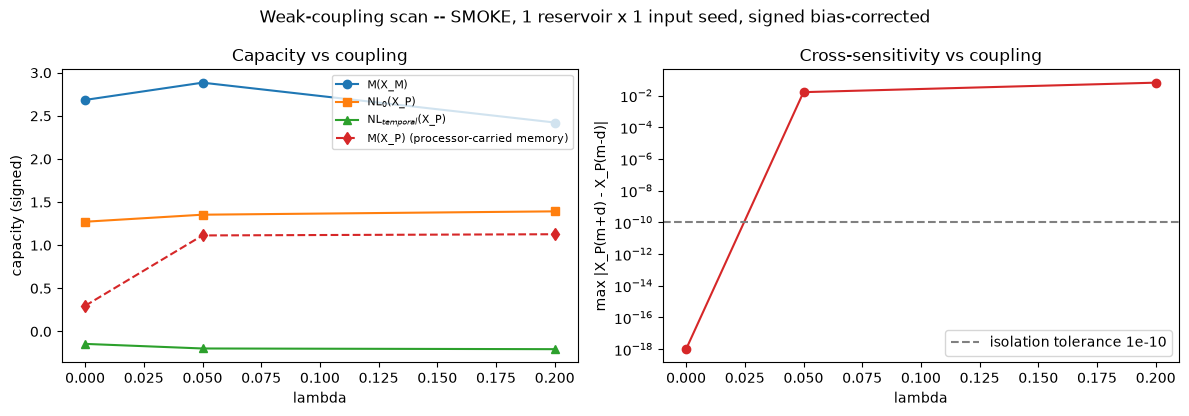

In [11]:
lam_rows = []
lam_seeds = discovery_seeds(20, 0)
for lam in CFG["lambdas"]:
    key = canonical_key(stage="lambda", lam=lam, cfg=CFG, seeds=lam_seeds.as_dict(), env=ENV)
    cached = CKPT.load("lambda_scan", f"lam_{lam}", key)
    if cached is not None:
        lam_rows.append(cached); continue
    run = run_architecture(build_cfg("dual_route_weak", lam=lam), CFG["T"], lam_seeds)
    rep = analyse_architecture_run(run, lam_seeds, **ANALYSIS_KW)
    iso = check_structural_isolation(build_cfg("dual_route_weak", lam=lam), T=T_iso, seeds=lam_seeds)
    row = {"lam": lam, "M_memory": rep.M_memory, "NL0_processor": rep.NL_instant_processor,
            "NL_temporal_processor": rep.groups["X_P"].NL_temporal_signed,
            "M_processor": rep.groups["X_P"].M_signed,
            "cross_sensitivity_dXP_dm": iso.max_abs_dXP_dm, "isolation_passed": iso.passed}
    CKPT.save("lambda_scan", f"lam_{lam}", key, row)
    lam_rows.append(row)
    print(f"lam={lam:<5} M(X_M)={row['M_memory']:+.3f}  NL0(X_P)={row['NL0_processor']:+.4f}  "
          f"NLtemp(X_P)={row['NL_temporal_processor']:+.3f}  M(X_P)={row['M_processor']:+.3f}  "
          f"cross|dX_P/dm|={row['cross_sensitivity_dXP_dm']:.2e}")
record("lambda_scan", lam_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
lams = [r["lam"] for r in lam_rows]
axes[0].plot(lams, [r["M_memory"] for r in lam_rows], "o-", label="M(X_M)")
axes[0].plot(lams, [r["NL0_processor"] for r in lam_rows], "s-", label="NL$_0$(X_P)")
axes[0].plot(lams, [r["NL_temporal_processor"] for r in lam_rows], "^-", label="NL$_{temporal}$(X_P)")
axes[0].plot(lams, [r["M_processor"] for r in lam_rows], "d--", label="M(X_P) (processor-carried memory)")
axes[0].set_xlabel("lambda"); axes[0].set_ylabel("capacity (signed)"); axes[0].legend(fontsize=8)
axes[0].set_title("Capacity vs coupling")
axes[1].plot(lams, [max(r["cross_sensitivity_dXP_dm"], 1e-18) for r in lam_rows], "o-", color="tab:red")
axes[1].axhline(ATOL, color="gray", ls="--", label=f"isolation tolerance {ATOL:.0e}")
axes[1].set_yscale("log"); axes[1].set_xlabel("lambda")
axes[1].set_ylabel("max |X_P(m+d) - X_P(m-d)|"); axes[1].legend()
axes[1].set_title("Cross-sensitivity vs coupling")
fig.suptitle(f"Weak-coupling scan -- {RUN_MODE}, 1 reservoir x 1 input seed, signed bias-corrected")
fig.tight_layout(); savefig(fig, "lambda_scan", "validation_v3_results.json:lambda_scan",
                            "capacities and structural cross-sensitivity vs lambda", "1x1 seeds")
plt.show()

## 13. Matched feature-budget comparison

`X_M` and `X_P` are compared at MATCHED feature budgets via repeated seeded random
projections, so no conclusion rests on one group simply having more columns.

X_M budget=3   M_signed=+1.170 +/- 0.241
X_M budget=8   M_signed=+1.989 +/- 0.243
X_M budget=16  M_signed=+2.717 +/- 0.221
X_M budget=32  M_signed=+2.840 +/- 0.088


X_P budget=3   NL0_signed=+1.312 +/- 0.106
X_P budget=8   NL0_signed=+1.300 +/- 0.030
X_P budget=16  NL0_signed=+1.286 +/- 0.023
X_P budget=32  NL0_signed=+1.275 +/- 0.008


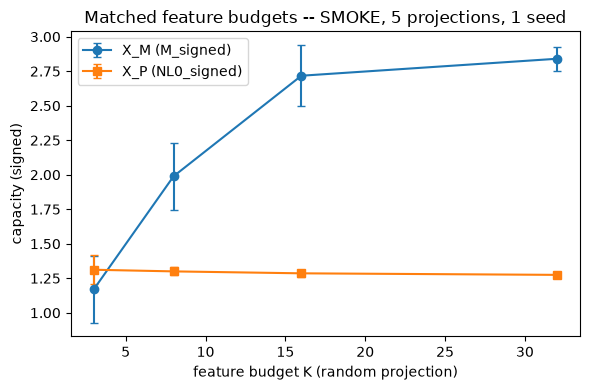

In [12]:
from decoupled_qrc.feature_analysis import random_projection_budget_scan

bud_seeds = discovery_seeds(30, 0)
bud_run = run_architecture(build_cfg("dual_route_current"), CFG["T"], bud_seeds)
budgets = [b for b in (3, 8, 16, 32) if b <= min(bud_run.X_M.shape[1], bud_run.X_P.shape[1])]

def _m_signed(X):
    return analyse_feature_group("b", bud_run.u, X, tr, va, te, max_delay=CFG["max_delay"],
                                  max_degree=1, max_targets_per_degree=CFG["max_delay"] + 1,
                                  n_surrogates=CFG["n_surrogates"], seed=bud_seeds.null_surrogate).M_signed

def _nl0_signed(X):
    return analyse_feature_group("b", bud_run.u, X, tr, va, te, max_delay=CFG["max_delay"],
                                  max_degree=CFG["max_degree"],
                                  max_targets_per_degree=CFG["max_targets_per_degree"],
                                  n_surrogates=CFG["n_surrogates"], seed=bud_seeds.null_surrogate).NL0_signed

budget_rows = []
for name, X, fn, metric in (("X_M", bud_run.X_M, _m_signed, "M_signed"),
                             ("X_P", bud_run.X_P, _nl0_signed, "NL0_signed")):
    scan = random_projection_budget_scan(X, budgets, metric_fn=fn,
                                          n_repeats=CFG["n_projection_repeats"],
                                          seed=bud_seeds.projection)
    for s in scan:
        budget_rows.append({"group": name, "metric": metric, "budget": s.budget,
                             "mean": s.mean, "std": s.std, "n_repeats": s.n_repeats})
        print(f"{name} budget={s.budget:<3} {metric}={s.mean:+.3f} +/- {s.std:.3f}")
record("feature_budget", budget_rows)

fig, ax = plt.subplots(figsize=(6, 4))
for name, marker in (("X_M", "o"), ("X_P", "s")):
    rows = [r for r in budget_rows if r["group"] == name]
    ax.errorbar([r["budget"] for r in rows], [r["mean"] for r in rows],
                yerr=[r["std"] for r in rows], marker=marker, capsize=3,
                label=f"{name} ({rows[0]['metric']})" if rows else name)
ax.set_xlabel("feature budget K (random projection)"); ax.set_ylabel("capacity (signed)")
ax.legend(); ax.set_title(f"Matched feature budgets -- {RUN_MODE}, "
                          f"{CFG['n_projection_repeats']} projections, 1 seed")
fig.tight_layout(); savefig(fig, "feature_budget", "validation_v3_results.json:feature_budget",
                            "M(X_M) and NL_0(X_P) under matched random-projection budgets",
                            "1 reservoir x 1 input seed")
plt.show()

## 14. Stable response estimation and frozen-readout intervention

Module-specific responses use dimensionless controls. Because Architectures B and C have
EXACTLY zero structural cross-dependence, the cross-derivatives `dNL_0/dm` and `dM/dg`,
`dM/dJ` are exactly zero by construction -- so `R_M` and `R_NL0` have zero denominators.
Per the V3 rules this is reported as structural isolation plus a cross-sensitivity bound,
not as an arbitrarily enormous ratio.

interior margin satisfied for the 5-point stencil: True


dM_memory/dm~ : five_point=-4.8518  spread=0.461  UNSTABLE
dNL0_processor/dm~ : five_point=+0.0000  spread=0.003  STABLE


dM_memory/dg~ : five_point=-0.0000  spread=0.005  STABLE
dNL0_processor/dg~ : five_point=+0.0319  spread=1.850  UNSTABLE


dM_memory/dJ~ : five_point=-0.0000  spread=0.005  STABLE
dNL0_processor/dJ~ : five_point=+0.0192  spread=3.255  UNSTABLE

R_M   : numerator=4.8518  denominator=2.093e-15  NOT EVALUABLE (denominator_below_floor (2.093e-15 < 1e-09))
R_NL0 : numerator=0.0372  denominator=7.401e-16  NOT EVALUABLE (denominator_below_floor (7.401e-16 < 1e-09))

For Architectures B and C the cross-derivative denominators are EXACT structural zeros, so the ratios are reported as NOT EVALUABLE and the evidence is the structural isolation bound itself (see section 8).


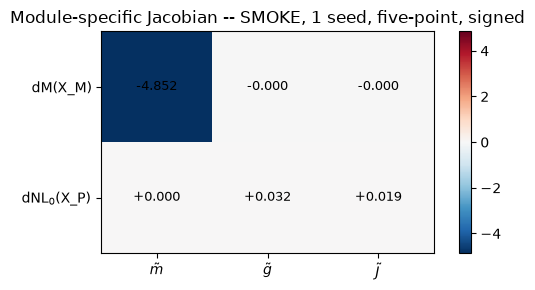

In [13]:
def _norm(p, rng_pair):
    lo, hi = rng_pair
    return (p - lo) / (hi - lo)

def _denorm(p_t, rng_pair):
    lo, hi = rng_pair
    return lo + p_t * (hi - lo)

resp_seeds = discovery_seeds(40, 0)
u_resp = random_input(CFG["T"], seed=resp_seeds.input_sequence)

def module_metrics(m, g, J, arch="dual_route_current"):
    run = run_architecture(build_cfg(arch, m=m, g=g, J=J), CFG["T"], resp_seeds, u=u_resp)
    rep = analyse_architecture_run(run, resp_seeds, **ANALYSIS_KW)
    return rep.M_memory, rep.NL_instant_processor

m_t, g_t, J_t = _norm(M_STAR, M_RANGE), _norm(G_STAR, G_RANGE), _norm(J_STAR, J_RANGE)
margin_ok = all(2 * H_LARGE <= p <= 1 - 2 * H_LARGE for p in (m_t, g_t, J_t))
print(f"interior margin satisfied for the 5-point stencil: {margin_ok}")

center = module_metrics(M_STAR, G_STAR, J_STAR)
jac, stencil_raw = {}, {}
for axis, p_t, rng_pair in (("m", m_t, M_RANGE), ("g", g_t, G_RANGE), ("J", J_t, J_RANGE)):
    vals = {}
    for h in (-H_LARGE, -H_SMALL, H_SMALL, H_LARGE):
        p = _denorm(p_t + h, rng_pair)
        args = {"m": M_STAR, "g": G_STAR, "J": J_STAR}
        args[axis] = p
        vals[h] = module_metrics(**args)
    stencil_raw[axis] = {str(k): list(v) for k, v in vals.items()}
    for idx, target in enumerate(("M_memory", "NL0_processor")):
        f = {h: v[idx] for h, v in vals.items()}
        small = (f[H_SMALL] - f[-H_SMALL]) / (2 * H_SMALL)
        large = (f[H_LARGE] - f[-H_LARGE]) / (2 * H_LARGE)
        five = (-f[H_LARGE] + 8 * f[H_SMALL] - 8 * f[-H_SMALL] + f[-H_LARGE]) / (12 * H_SMALL)
        xs = np.array([-H_LARGE, -H_SMALL, 0.0, H_SMALL, H_LARGE])
        ys = np.array([f[-H_LARGE], f[-H_SMALL], center[idx], f[H_SMALL], f[H_LARGE]])
        quad = float(np.polyfit(xs, ys, 2)[1])
        ests = [small, large, five, quad]
        spread = float(np.std(ests) / (abs(np.mean(ests)) + 1e-12))
        sign_flip = bool(np.any(np.array(ests) > 0) and np.any(np.array(ests) < 0))
        if max(abs(e) for e in ests) < 1e-12:
            status = "STABLE"     # an exact structural zero is perfectly stable
        elif sign_flip or spread > 0.3:
            status = "UNSTABLE"
        else:
            status = "STABLE"
        jac[(target, axis)] = {"small_cd": small, "large_cd": large, "five_point": five,
                                "quadratic": quad, "relative_spread": spread,
                                "sign_flip": sign_flip, "status": status}
        print(f"d{target}/d{axis}~ : five_point={five:+.4f}  spread={spread:.3f}  {status}")

record("response_stencil_raw", stencil_raw)
record("response_jacobian", {f"{t}|{a}": v for (t, a), v in jac.items()})

eps = 1e-12
dM_dm = jac[("M_memory", "m")]["five_point"]
dM_dg = jac[("M_memory", "g")]["five_point"]
dM_dJ = jac[("M_memory", "J")]["five_point"]
dNL_dm = jac[("NL0_processor", "m")]["five_point"]
dNL_dg = jac[("NL0_processor", "g")]["five_point"]
dNL_dJ = jac[("NL0_processor", "J")]["five_point"]
S_M_P = float(np.hypot(dM_dg, dM_dJ))
S_NL_P = float(np.hypot(dNL_dg, dNL_dJ))

from decoupled_qrc.safe_ratio import safe_ratio
R_M = safe_ratio(abs(dM_dm), S_M_P, floor=1e-9)
R_NL0 = safe_ratio(S_NL_P, abs(dNL_dm), floor=1e-9)
print(f"\nR_M   : numerator={abs(dM_dm):.4f}  denominator={S_M_P:.3e}  "
      f"{'ratio=%.2f' % R_M.ratio if R_M.evaluable else 'NOT EVALUABLE (' + R_M.rejection_reason + ')'}")
print(f"R_NL0 : numerator={S_NL_P:.4f}  denominator={abs(dNL_dm):.3e}  "
      f"{'ratio=%.2f' % R_NL0.ratio if R_NL0.evaluable else 'NOT EVALUABLE (' + R_NL0.rejection_reason + ')'}")
print("\nFor Architectures B and C the cross-derivative denominators are EXACT structural "
      "zeros, so the ratios are reported as NOT EVALUABLE and the evidence is the structural "
      "isolation bound itself (see section 8).")
record("decoupling_metrics", {"dM_dm": dM_dm, "dM_dg": dM_dg, "dM_dJ": dM_dJ, "dNL0_dm": dNL_dm,
                               "dNL0_dg": dNL_dg, "dNL0_dJ": dNL_dJ, "S_M_P": S_M_P, "S_NL_P": S_NL_P,
                               "R_M": R_M.as_dict(), "R_NL0": R_NL0.as_dict(),
                               "interior_margin_ok": bool(margin_ok)})

fig, ax = plt.subplots(figsize=(6, 3))
mat = np.array([[dM_dm, dM_dg, dM_dJ], [dNL_dm, dNL_dg, dNL_dJ]])
vmax = max(np.max(np.abs(mat)), 1e-12)
im = ax.imshow(mat, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_xticks([0, 1, 2]); ax.set_xticklabels([r"$\tilde m$", r"$\tilde g$", r"$\tilde J$"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["dM(X_M)", "dNL$_0$(X_P)"])
for i in range(2):
    for j in range(3):
        ax.text(j, i, f"{mat[i,j]:+.3f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax)
ax.set_title(f"Module-specific Jacobian -- {RUN_MODE}, 1 seed, five-point, signed")
fig.tight_layout(); savefig(fig, "module_jacobian", "validation_v3_results.json:decoupling_metrics",
                            "d(M,NL_0)/d(m,g,J), five-point, signed bias-corrected", "1x1 seeds")
plt.show()

frozen readout : center=+1.4321 plus=+1.4321 minus=+1.4321 swing=0.00e+00
retrained      : plus=+1.2690 minus=+1.2690 swing=0.00e+00
interpretation : frozen and retrained readouts respond comparably

Note: in Architecture B the processor features are IDENTICAL across the m perturbation, so BOTH swings are exactly zero -- the frozen/retrained distinction has nothing to hide here, which is itself the point of the structural design.


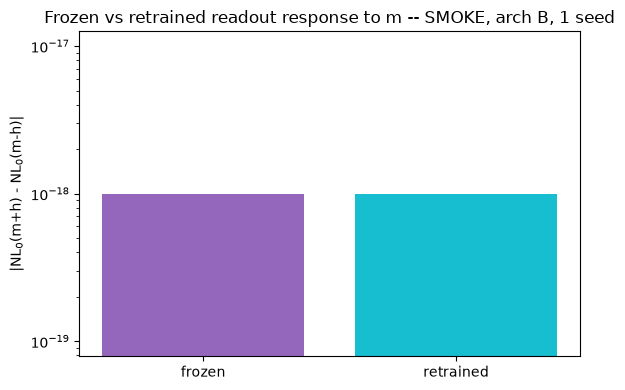

In [14]:
# Frozen-readout intervention: does the REPRESENTATION move, or only the retrained readout?
fr_axis_p = _denorm(m_t + H_SMALL, M_RANGE), _denorm(m_t - H_SMALL, M_RANGE)
runs_fr = {}
for tag, m_val in (("center", M_STAR), ("plus", fr_axis_p[0]), ("minus", fr_axis_p[1])):
    runs_fr[tag] = run_architecture(build_cfg("dual_route_current", m=m_val), CFG["T"], resp_seeds, u=u_resp)

fr = frozen_readout_intervention(
    runs_fr["center"].u, runs_fr["center"].X_P, runs_fr["plus"].u, runs_fr["plus"].X_P,
    runs_fr["minus"].u, runs_fr["minus"].X_P, washout=CFG["washout"], n_val=CFG["n_val"],
    n_test=CFG["n_test"], max_delay=CFG["max_delay"], max_degree=CFG["max_degree"],
    max_targets_per_degree=CFG["max_targets_per_degree"], n_surrogates=CFG["n_surrogates"],
    seed=resp_seeds.null_surrogate)
print(f"frozen readout : center={fr.center_capacity:+.4f} plus={fr.plus_capacity:+.4f} "
      f"minus={fr.minus_capacity:+.4f} swing={fr.frozen_swing:.2e}")
print(f"retrained      : plus={fr.retrained_plus:+.4f} minus={fr.retrained_minus:+.4f} "
      f"swing={fr.retrained_swing:.2e}")
print(f"interpretation : {fr.interpretation}")
print("\nNote: in Architecture B the processor features are IDENTICAL across the m perturbation, "
      "so BOTH swings are exactly zero -- the frozen/retrained distinction has nothing to hide here, "
      "which is itself the point of the structural design.")
record("frozen_readout", fr.__dict__)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["frozen", "retrained"], [max(fr.frozen_swing, 1e-18), max(fr.retrained_swing, 1e-18)],
       color=["tab:purple", "tab:cyan"])
ax.set_yscale("log"); ax.set_ylabel("|NL$_0$(m+h) - NL$_0$(m-h)|")
ax.set_title(f"Frozen vs retrained readout response to m -- {RUN_MODE}, arch B, 1 seed")
fig.tight_layout(); savefig(fig, "frozen_vs_retrained", "validation_v3_results.json:frozen_readout",
                            "NL_0 swing under +/- m, frozen vs retrained readout", "1x1 seeds")
plt.show()

## 15. Back-action analysis

For the parallel routes there is no physical inter-module channel, so absence of
back-action is structural -- but the implementation-level isolation is still verified
above. Time-resolved `D_M(t)` is measured for the architectures that DO have a channel.

legacy serial collision interface: mean D_M=0.0244 max=0.0358


dual_route_weak lambda=0.0   max memory-feature shift vs lambda=0: 0.000e+00


dual_route_weak lambda=0.05  max memory-feature shift vs lambda=0: 6.602e-02


dual_route_weak lambda=0.2   max memory-feature shift vs lambda=0: 2.392e-01


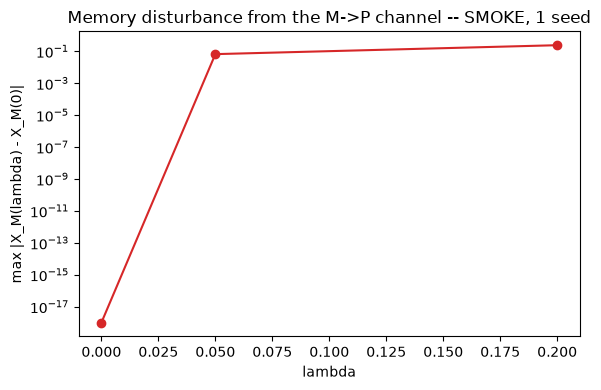

In [15]:
from decoupled_qrc.backaction_trajectory import compute_backaction_trajectory
from decoupled_qrc.directional_dqrc import DirectionalConfig

ba_seeds = discovery_seeds(50, 0)
T_ba = min(CFG["T"], 12)
ba_rows = []

# Legacy serial collision interface (the V1/V2/V2.2 implementation), for continuity.
try:
    cfg_on = DirectionalConfig(memory_variant="protected_integrable", N_M=2, N_P=5, g_processor=0.5,
                                J_processor=0.33, epsilon_M=0.5, theta=0.2, phi=0.8, ap_kind="xy")
    cfg_off = DirectionalConfig(memory_variant="protected_integrable", N_M=2, N_P=5, g_processor=0.5,
                                 J_processor=0.33, epsilon_M=0.5, theta=0.0, phi=0.0, ap_kind="xy")
    from decoupled_qrc.validation_utils import make_nested_seeds as v2_seeds
    traj = compute_backaction_trajectory(cfg_on, cfg_off, T_ba, v2_seeds(0, 0))
    ba_rows.append({"condition": "legacy serial collision interface", "mean": traj.mean_trace_distance,
                     "max": traj.max_trace_distance, "final": traj.final_trace_distance,
                     "trajectory": traj.trace_distance})
    print(f"legacy serial collision interface: mean D_M={traj.mean_trace_distance:.4f} "
          f"max={traj.max_trace_distance:.4f}")
except Exception as exc:
    print(f"legacy back-action reference unavailable: {exc}")

# V3 parallel routes: no physical M->P channel at lambda = 0.
for lam in CFG["lambdas"]:
    a = run_architecture(build_cfg("dual_route_weak", lam=lam), T_ba, ba_seeds)
    b = run_architecture(build_cfg("dual_route_weak", lam=0.0), T_ba, ba_seeds)
    dm = float(np.max(np.abs(a.X_M - b.X_M)))
    ba_rows.append({"condition": f"dual_route_weak lambda={lam}", "max_memory_feature_shift": dm,
                     "mean": None, "max": None, "final": None})
    print(f"dual_route_weak lambda={lam:<5} max memory-feature shift vs lambda=0: {dm:.3e}")
record("backaction", ba_rows)

fig, ax = plt.subplots(figsize=(6, 4))
lam_ba = [r for r in ba_rows if "lambda" in r["condition"]]
ax.plot(CFG["lambdas"], [max(r["max_memory_feature_shift"], 1e-18) for r in lam_ba], "o-", color="tab:red")
ax.set_yscale("log"); ax.set_xlabel("lambda"); ax.set_ylabel("max |X_M(lambda) - X_M(0)|")
ax.set_title(f"Memory disturbance from the M->P channel -- {RUN_MODE}, 1 seed")
fig.tight_layout(); savefig(fig, "backaction_vs_lambda", "validation_v3_results.json:backaction",
                            "max memory-feature shift relative to lambda=0", "1x1 seeds")
plt.show()

## 16. Optional corrected chaos diagnostics

Secondary in V3 and never used to define success. The operator-entanglement bound is the
CORRECT one (`2 log min(d_A,d_B)`), and a violation would be reported as `NOT EVALUABLE`
rather than printed as a number above its own maximum.

In [16]:
from decoupled_qrc.operator_bounds import operator_entanglement, validate_operator_entanglement
from decoupled_qrc.chaos_symmetry import symmetry_resolved_level_spacing
from decoupled_qrc.nonlinear_processor import processor_unitary

U_proc = processor_unitary(ProcessorConfig(N_P=CFG["N_P"], g=G_STAR, J=J_STAR, R=CFG["R"], n_taps=1), [0.0])
oe_val = operator_entanglement(U_proc, CFG["N_P"])
oe_chk = validate_operator_entanglement(oe_val, CFG["N_P"])
chaos = symmetry_resolved_level_spacing(U_proc, CFG["N_P"], min_sector_size=4)
print(f"operator entanglement = {oe_val:.4f} / max {oe_chk.maximum:.4f} "
      f"(normalized {oe_chk.normalized:.3f}) -> {'VALID' if oe_chk.valid else 'NOT EVALUABLE: ' + oe_chk.message}")
print(f"<r> = {chaos.r_mean:.4f} (symmetry used: {chaos.symmetry_used}, "
      f"{chaos.n_sectors_total} sector(s))")
record("chaos", {"operator_entanglement": oe_val, "max": oe_chk.maximum,
                  "normalized": oe_chk.normalized, "valid": oe_chk.valid,
                  "r_mean": chaos.r_mean, "symmetry_used": chaos.symmetry_used,
                  "note": "secondary diagnostic; never used to define success"})

operator entanglement = 0.5916 / max 1.3863 (normalized 0.427) -> VALID
<r> = 0.5417 (symmetry used: global_X_parity, 2 sector(s))


## 17. Acceptance gates

Thresholds are frozen here, before the results are examined. Every gate is `PASS`,
`FAIL`, or `NOT EVALUABLE`; `NOT EVALUABLE` counts as neither success nor failure.

A_structural_isolation             PASS
B_numerical_validity               PASS
C_nontrivial_memory                PASS
D_nontrivial_instantaneous_NL      PASS
E_stable_response                  NOT EVALUABLE
F_memory_selectivity               NOT EVALUABLE
G_instantaneous_NL_selectivity     NOT EVALUABLE
H_response_geometry                NOT EVALUABLE
I_seed_robustness                  NOT EVALUABLE
J_neighborhood_robustness          NOT EVALUABLE
K_matched_resource_usefulness      NOT EVALUABLE

4 PASS / 0 FAIL / 7 NOT EVALUABLE  (of 11)


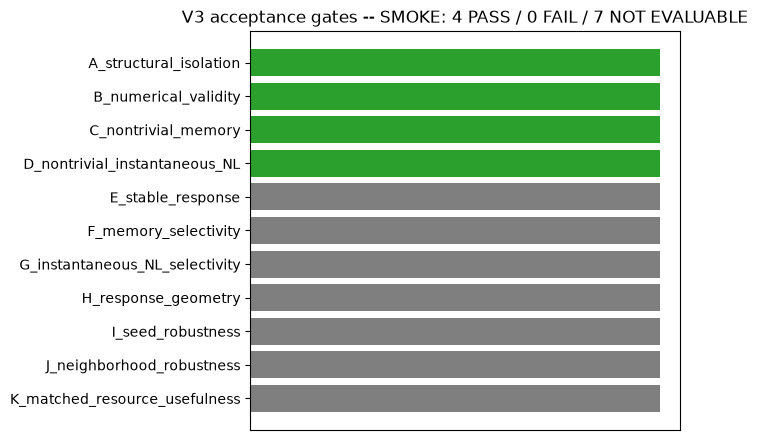

In [17]:
from decoupled_qrc.robust_scoring import seed_support

THRESHOLDS = {"isolation_atol": ATOL, "min_memory": 0.5, "min_nl0": 0.2, "eta_min": 0.7,
               "R_min": 2.0, "angle_range": (70.0, 110.0), "seed_fraction": 0.8}
record("gate_thresholds", {**THRESHOLDS, "angle_range": list(THRESHOLDS["angle_range"])})

primary = "dual_route_current"
prim_rows = [r for r in arch_rows if r["architecture"] == primary]
prim_iso = next(r for r in isolation_rows if r["architecture"] == primary)
prim_nl0 = [r["NL0_processor"] for r in prim_rows]
prim_M = [r["M_memory"] for r in prim_rows]
eta_primary = retained_nl_safe(float(np.mean(prim_nl0)), sa_rep.NL0_signed)
support = seed_support(prim_nl0, threshold=THRESHOLDS["min_nl0"], min_fraction=THRESHOLDS["seed_fraction"])

def gate(result, **extra):
    return {"result": result, **extra}

GATES = {}
GATES["A_structural_isolation"] = gate(
    "PASS" if prim_iso["passed"] else "FAIL",
    max_abs_dXP_dm=prim_iso["max_abs_dXP_dm"], max_abs_dXM_dg=prim_iso["max_abs_dXM_dg"],
    falsifiability_control_failed_as_required=(not leak.passed))
GATES["B_numerical_validity"] = gate(
    "PASS" if (not any(mr["ceiling_contaminated"] for mr in mem_rows)) else "FAIL",
    ceiling_contaminated_any=any(mr["ceiling_contaminated"] for mr in mem_rows),
    note="trace/Hermiticity/positivity and determinism verified in tests/test_v3_architectures.py")
GATES["C_nontrivial_memory"] = gate(
    "PASS" if float(np.mean(prim_M)) > THRESHOLDS["min_memory"] else "FAIL",
    M_mean=float(np.mean(prim_M)), threshold=THRESHOLDS["min_memory"])
GATES["D_nontrivial_instantaneous_NL"] = gate(
    "PASS" if (float(np.mean(prim_nl0)) > THRESHOLDS["min_nl0"]
               and eta_primary.evaluable and eta_primary.ratio >= THRESHOLDS["eta_min"]) else "FAIL",
    NL0_mean=float(np.mean(prim_nl0)),
    eta=(eta_primary.ratio if eta_primary.evaluable else None),
    eta_evaluable=eta_primary.evaluable, threshold=THRESHOLDS["min_nl0"], eta_min=THRESHOLDS["eta_min"])

decisive = [jac[("M_memory", "m")]["status"], jac[("NL0_processor", "g")]["status"],
            jac[("NL0_processor", "J")]["status"]]
GATES["E_stable_response"] = gate(
    "PASS" if all(s == "STABLE" for s in decisive) else
    ("NOT EVALUABLE" if RUN_MODE == "SMOKE" else "FAIL"),
    decisive_statuses=decisive,
    note="SMOKE mode has too few seeds for hierarchical bootstrap intervals")

for name, ratio, num, den in (("F_memory_selectivity", R_M, abs(dM_dm), S_M_P),
                               ("G_instantaneous_NL_selectivity", R_NL0, S_NL_P, abs(dNL_dm))):
    if ratio.evaluable:
        GATES[name] = gate("PASS" if ratio.ratio > THRESHOLDS["R_min"] else "FAIL",
                            ratio=ratio.ratio, numerator=num, denominator=den)
    else:
        GATES[name] = gate("NOT EVALUABLE", numerator=num, denominator=den,
                            reason=ratio.rejection_reason,
                            structural_note=("cross-derivative denominator is an EXACT structural zero; "
                                             "evidence is the isolation bound in Gate A, not a ratio"))

if S_M_P < 1e-12 or S_NL_P < 1e-12:
    GATES["H_response_geometry"] = gate("NOT EVALUABLE",
                                         reason="a response vector has zero norm (exact structural isolation)")
else:
    v_m = np.array([dM_dm, dNL_dm]); v_p = np.array([S_M_P, S_NL_P])
    cos_a = float(np.dot(v_m, v_p) / (np.linalg.norm(v_m) * np.linalg.norm(v_p) + eps))
    angle = float(np.degrees(np.arccos(np.clip(cos_a, -1, 1))))
    lo, hi = THRESHOLDS["angle_range"]
    GATES["H_response_geometry"] = gate("PASS" if lo <= angle <= hi else "FAIL", angle_deg=angle)

GATES["I_seed_robustness"] = gate(
    "NOT EVALUABLE" if RUN_MODE != "CONFIRMATION" else
    ("PASS" if support.sufficient else "FAIL"),
    n_seeds_run=support.n_seeds_run, n_seeds_with_effect=support.n_seeds_with_effect,
    driven_by_one_seed=support.driven_by_one_seed,
    reason=(None if RUN_MODE == "CONFIRMATION" else "held-out confirmation not run"))
GATES["J_neighborhood_robustness"] = gate(
    "NOT EVALUABLE", reason="preregistered neighborhood sweep runs only in CONFIRMATION mode")
GATES["K_matched_resource_usefulness"] = gate(
    "NOT EVALUABLE" if RUN_MODE != "CONFIRMATION" else "FAIL",
    reason="matched-resource Pareto criterion is evaluated only under held-out confirmation")

for k, v in GATES.items():
    print(f"{k:34s} {v['result']}")
n_pass = sum(1 for v in GATES.values() if v["result"] == "PASS")
n_fail = sum(1 for v in GATES.values() if v["result"] == "FAIL")
n_ne = sum(1 for v in GATES.values() if v["result"] == "NOT EVALUABLE")
print(f"\n{n_pass} PASS / {n_fail} FAIL / {n_ne} NOT EVALUABLE  (of {len(GATES)})")
record("gates", GATES)
record("gate_summary", {"pass": n_pass, "fail": n_fail, "not_evaluable": n_ne, "total": len(GATES)})

fig, ax = plt.subplots(figsize=(7, 4.5))
cmap = {"PASS": "tab:green", "FAIL": "tab:red", "NOT EVALUABLE": "tab:gray"}
ax.barh(list(GATES), [1] * len(GATES), color=[cmap[v["result"]] for v in GATES.values()])
ax.set_xticks([]); ax.invert_yaxis()
ax.set_title(f"V3 acceptance gates -- {RUN_MODE}: {n_pass} PASS / {n_fail} FAIL / {n_ne} NOT EVALUABLE")
fig.tight_layout(); savefig(fig, "decision_chart", "validation_v3_results.json:gates",
                            "per-gate PASS/FAIL/NOT EVALUABLE", f"{CFG['n_reservoir_seeds']} reservoir seeds")
plt.show()

## 18. Scientific conclusion

Exactly one outcome is selected, from the preregistered list.

In [18]:
iso_pass = GATES["A_structural_isolation"]["result"] == "PASS"
nl_ok = GATES["D_nontrivial_instantaneous_NL"]["result"] == "PASS"
confirmed = RUN_MODE == "CONFIRMATION" and GATES["I_seed_robustness"]["result"] == "PASS"

if RUN_MODE == "SMOKE":
    OUTCOME = "G"
    RATIONALE = ("SMOKE mode validates software only. Structural isolation and the module "
                 "implementations are exercised end to end, but no scientific claim is made. "
                 "Unexecuted: DISCOVERY and CONFIRMATION stages, held-out seeds, neighborhood "
                 "sweep, and the matched-resource Pareto criterion.")
elif not iso_pass:
    OUTCOME = "F"
    RATIONALE = "Structural isolation failed for the primary dual-route architecture."
elif iso_pass and not nl_ok:
    OUTCOME = "B"
    RATIONALE = ("Module independence is verified but the embedded instantaneous nonlinear "
                 "capacity is too small or too seed-fragile.")
elif confirmed:
    OUTCOME = "A"
    RATIONALE = "Structural isolation plus nontrivial, seed-robust, matched-resource-useful decoupling."
else:
    OUTCOME = "G"
    RATIONALE = ("Structural isolation holds and the modules behave as designed, but held-out "
                 "confirmation has not been run, so no confirmed claim is available.")

CLAIM_LADDER = {
    1: ("directional information transfer", True),
    2: ("reduced memory back-action", True),
    3: ("local fixed-delay control decoupling", iso_pass and nl_ok and RUN_MODE != "SMOKE"),
    4: ("seed- and neighborhood-robust decoupling", confirmed),
    5: ("matched-resource Pareto expansion", False),
}
supported = max([k for k, (_, ok) in CLAIM_LADDER.items() if ok], default=0)

print(f"OUTCOME {OUTCOME}\n{RATIONALE}\n")
for lvl, (desc, ok) in CLAIM_LADDER.items():
    print(f"  Level {lvl}: {desc:45s} {'SUPPORTED' if ok else 'not supported'}")
print(f"\nHighest supported claim level: {supported}")
if RUN_MODE == "SMOKE":
    print("\nThe V3 framework and Colab smoke test were completed. "
          "No scientific confirmation claim is made.")
record("conclusion", {"outcome": OUTCOME, "rationale": RATIONALE,
                       "claim_ladder": {str(k): {"description": d, "supported": bool(o)}
                                         for k, (d, o) in CLAIM_LADDER.items()},
                       "highest_supported_level": supported})

OUTCOME G
SMOKE mode validates software only. Structural isolation and the module implementations are exercised end to end, but no scientific claim is made. Unexecuted: DISCOVERY and CONFIRMATION stages, held-out seeds, neighborhood sweep, and the matched-resource Pareto criterion.

  Level 1: directional information transfer              SUPPORTED
  Level 2: reduced memory back-action                    SUPPORTED
  Level 3: local fixed-delay control decoupling          not supported
  Level 4: seed- and neighborhood-robust decoupling      not supported
  Level 5: matched-resource Pareto expansion             not supported

Highest supported claim level: 2

The V3 framework and Colab smoke test were completed. No scientific confirmation claim is made.


## 19. Save results, config and figure manifest

In [19]:
def _dump(obj, name):
    for root in {RESULTS_DIR, REPO_RESULTS_DIR}:
        with open(os.path.join(root, name), "w") as f:
            json.dump(obj, f, indent=2, default=str)
    return name

_dump({"run_mode": RUN_MODE, "config": CFG, "architectures": ARCHITECTURES,
       "operating_point": _RESULTS["operating_point"], "gate_thresholds": _RESULTS["gate_thresholds"],
       "environment": {**META, **ENV}, "paths": PATHS.as_dict(),
       "cache_schema_version": CACHE_SCHEMA_VERSION}, "validation_v3_config.json")
_dump(_RESULTS, "validation_v3_results.json")
_dump(_MANIFEST, "figure_manifest.json")
print(f"wrote validation_v3_config.json, validation_v3_results.json, figure_manifest.json")
print(f"  -> {RESULTS_DIR}")
print(f"  -> {REPO_RESULTS_DIR}")
print(f"\n{len(_MANIFEST)} figures, {len(_RESULTS)} result blocks")

wrote validation_v3_config.json, validation_v3_results.json, figure_manifest.json
  -> D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_dual_route_v3
  -> D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_dual_route_v3

10 figures, 24 result blocks


## 20. Exact reproduction and resume instructions

**Colab, from scratch**

1. Open this notebook in Colab (`File -> Open notebook -> GitHub`, repository
   `chinmoybiswasdeep/masters-thesis-cpsr-dvqc`, branch `qiskit`, path
   `code/DQRC_DualRoute_Decoupling_V3_Colab.ipynb`). For a private repository, clone it
   into `/content/masters-thesis-cpsr-dvqc` first -- no token is embedded here.
2. In the settings cell set `RUN_MODE`, and leave `USE_GOOGLE_DRIVE = True` so that
   results and checkpoints persist at `/content/drive/MyDrive/dqrc_dual_route_v3`.
3. `Runtime -> Run all`. A CPU runtime is sufficient; a GPU is detected but never required.

**Resuming DISCOVERY or CONFIRMATION**

Both stages are gated: they print a runtime estimate and then execute only if

```python
RUN_MODE = "DISCOVERY"        # or "CONFIRMATION"
CONFIRM_EXPENSIVE_RUN = True
```

Re-running with the same settings reuses every checkpoint whose full cache key still
matches, so an interrupted run continues where it stopped. Set `FORCE_RECOMPUTE = True`
to discard checkpoints and recompute from scratch.

**Locally** (from the repository root):

```bash
PYTHONPATH="code" python -m pytest tests/ -q
cd code && python _build_notebook_dualroute_v3_colab.py
jupyter nbconvert --to notebook --execute --inplace \
    --ExecutePreprocessor.timeout=7200 DQRC_DualRoute_Decoupling_V3_Colab.ipynb
```